## Importando bibliotecas

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import csv
import numpy as np
import time
import re
from pathlib import Path
import seaborn as sns
from matplotlib.ticker import ScalarFormatter
import os

## Funcões:

In [30]:
def carregar_dataframes(pasta, NE, TCC, TCT, O):
    """
    Lê arquivos .dat com base nos parâmetros fornecidos.

    Argumentos:
    - pasta: caminho para o diretório onde estão os arquivos
    - NE: número de partículas boas
    - TCC: probabilidade de captura (ex: 0.95)
    - TCT: probabilidade de transformação (ex: 0.95)
    - O: número de obstáculos

    Retorna:
    - dicionário com os DataFrames, com chaves no formato "SR_TCC_{x}_SR_TCT_{y}"
    """
    dataframes = {}

    for sr_tcc in range(1, 51):
        for sr_tct in range(1, 51):
            nome_arquivo = f"NC_500_NE_{NE}_O_{O}_TCC_{TCC}_SR_{sr_tcc}_TCT_{TCT}_SR_{sr_tct}.dat_presas_por_passo.csv"
            caminho_arquivo = os.path.join(pasta, nome_arquivo)

            if os.path.exists(caminho_arquivo):
                try:
                    df = pd.read_csv(caminho_arquivo, sep=',')
                    chave = f"SR_TCC_{sr_tcc}_SR_TCT_{sr_tct}"
                    dataframes[chave] = df
                except Exception as e:
                    print(f"Erro ao ler {nome_arquivo}: {e}")
            else:
                print(f"Arquivo não encontrado: {nome_arquivo}")

    return dataframes


## Dados

In [7]:
base_path = Path.home() / "Dados_Doc" / "TCC_095" / "TCT_005" / "Distribuição_quadrada"/ "SR_5"
# O = 00
df_NP01_NH500_TCC_095_TCT_005_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_0_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_0_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_0_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_0_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_0_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_0_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_0_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_0_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_0_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_0_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_0_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_0_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_0_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_0_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_0_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
# O = 00
df_NP01_NH500_TCC_095_TCT_005_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_2_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_2_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_2_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_2_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_2_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_2_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_2_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_2_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_2_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_2_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_2_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_2_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_2_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_2_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_2_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
# O = 3
df_NP01_NH500_TCC_095_TCT_005_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_3_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_3_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_3_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_3_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_3_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_3_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_3_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_3_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_3_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_3_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_3_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_3_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_3_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_3_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_3_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
# O = 5
df_NP01_NH500_TCC_095_TCT_005_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_5_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_5_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_5_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_5_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_5_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_5_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_5_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_5_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_5_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_5_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_5_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_5_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_5_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_5_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_5_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
# # O = 6
df_NP01_NH500_TCC_095_TCT_005_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_6_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_6_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_6_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_6_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_6_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_6_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_6_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_6_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_6_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_6_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_6_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_6_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_6_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_6_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_6_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
# O = 11
df_NP01_NH500_TCC_095_TCT_005_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_11_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_11_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_11_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_11_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_11_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_11_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_11_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_11_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_11_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_11_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_11_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_11_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_11_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_11_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_11_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
# # O = 21
df_NP01_NH500_TCC_095_TCT_005_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_21_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_21_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_21_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_21_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_21_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_21_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_21_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_21_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_21_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_21_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_21_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_21_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_21_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_21_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_21_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
# # O = 26
df_NP01_NH500_TCC_095_TCT_005_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_26_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_26_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_26_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_26_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_26_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_26_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_26_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_26_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_26_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_26_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_26_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_26_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_26_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_26_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_26_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
# O = 51
df_NP01_NH500_TCC_095_TCT_005_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_51_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_51_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_51_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_51_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_51_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_51_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_51_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_51_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_51_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_51_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_51_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_51_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_51_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_51_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_51_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')

In [8]:
base_path = Path.home() / "Dados_Doc" / "TCC_095" / "TCT_005" / "Distribuição_quadrada"/ "SR_10"
#O = 00
df_NP01_NH500_TCC_095_TCT_005_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_0_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_0_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_0_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_0_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_0_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_0_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_0_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_0_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_0_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_0_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_0_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_0_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_0_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_0_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_0_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
# O = 00
df_NP01_NH500_TCC_095_TCT_005_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_2_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_2_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_2_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_2_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_2_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_2_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_2_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_2_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_2_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_2_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_2_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_2_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_2_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_2_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_2_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
# O = 3
df_NP01_NH500_TCC_095_TCT_005_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_3_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_3_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_3_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_3_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_3_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_3_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_3_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_3_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_3_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_3_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_3_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_3_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_3_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_3_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_3_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
# O = 5
df_NP01_NH500_TCC_095_TCT_005_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_5_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_5_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_5_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_5_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_5_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_5_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_5_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_5_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_5_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_5_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_5_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_5_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_5_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_5_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_5_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
# # O = 6
df_NP01_NH500_TCC_095_TCT_005_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_6_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_6_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_6_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_6_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_6_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_6_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_6_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_6_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_6_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_6_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_6_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_6_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_6_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_6_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_6_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
# O = 11
df_NP01_NH500_TCC_095_TCT_005_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_11_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_11_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_11_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_11_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_11_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_11_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_11_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_11_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_11_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_11_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_11_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_11_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_11_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_11_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_11_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
# # O = 21
df_NP01_NH500_TCC_095_TCT_005_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_21_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_21_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_21_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_21_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_21_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_21_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_21_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_21_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_21_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_21_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_21_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_21_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_21_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_21_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_21_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
# # O = 26
df_NP01_NH500_TCC_095_TCT_005_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_26_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_26_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_26_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_26_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_26_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_26_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_26_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_26_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_26_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_26_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_26_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_26_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_26_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_26_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_26_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
# O = 51
df_NP01_NH500_TCC_095_TCT_005_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_51_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_51_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_51_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_51_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_51_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_51_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_51_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_51_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_51_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_51_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_51_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_51_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_51_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_51_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_51_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')

In [9]:
base_path = Path.home() / "Dados_Doc" / "TCC_095" / "TCT_005" / "Distribuição_quadrada"/ "SR_20"
# O = 00
df_NP01_NH500_TCC_095_TCT_005_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_0_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_0_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_0_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_0_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_0_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_0_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_0_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_0_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_0_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_0_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_0_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_0_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_0_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_0_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_0_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
# O = 00
df_NP01_NH500_TCC_095_TCT_005_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_2_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_2_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_2_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_2_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_2_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_2_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_2_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_2_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_2_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_2_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_2_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_2_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_2_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_2_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_2_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
# O = 3
df_NP01_NH500_TCC_095_TCT_005_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_3_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_3_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_3_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_3_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_3_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_3_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_3_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_3_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_3_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_3_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_3_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_3_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_3_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_3_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_3_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
# O = 5
df_NP01_NH500_TCC_095_TCT_005_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_5_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_5_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_5_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_5_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_5_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_5_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_5_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_5_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_5_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_5_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_5_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_5_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_5_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_5_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_5_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
# # O = 6
df_NP01_NH500_TCC_095_TCT_005_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_6_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_6_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_6_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_6_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_6_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_6_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_6_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_6_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_6_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_6_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_6_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_6_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_6_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_6_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_6_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
# O = 11
df_NP01_NH500_TCC_095_TCT_005_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_11_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_11_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_11_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_11_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_11_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_11_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_11_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_11_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_11_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_11_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_11_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_11_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_11_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_11_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_11_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
# # O = 21
df_NP01_NH500_TCC_095_TCT_005_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_21_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_21_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_21_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_21_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_21_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_21_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_21_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_21_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_21_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_21_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_21_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_21_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_21_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_21_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_21_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
# # O = 26
df_NP01_NH500_TCC_095_TCT_005_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_26_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_26_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_26_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_26_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_26_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_26_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_26_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_26_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_26_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_26_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_26_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_26_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_26_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_26_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_26_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
# O = 51
df_NP01_NH500_TCC_095_TCT_005_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_51_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_51_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_51_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_51_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_51_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_51_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_51_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_51_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_51_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_51_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_51_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_51_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_51_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_51_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_51_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')

In [10]:
base_path = Path.home() / "Dados_Doc" / "TCC_095" / "TCT_005" / "Distribuição_quadrada"/ "SR_30"
# O = 00
df_NP01_NH500_TCC_095_TCT_005_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_0_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_0_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_0_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_0_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_0_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_0_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_0_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_0_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_0_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_0_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_0_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_0_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_0_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_0_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_0_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
# O = 00
df_NP01_NH500_TCC_095_TCT_005_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_2_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_2_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_2_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_2_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_2_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_2_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_2_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_2_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_2_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_2_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_2_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_2_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_2_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_2_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_2_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
# O = 3
df_NP01_NH500_TCC_095_TCT_005_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_3_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_3_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_3_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_3_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_3_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_3_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_3_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_3_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_3_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_3_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_3_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_3_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_3_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_3_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_3_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
# O = 5
df_NP01_NH500_TCC_095_TCT_005_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_5_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_5_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_5_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_5_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_5_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_5_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_5_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_5_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_5_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_5_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_5_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_5_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_5_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_5_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_5_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
# # O = 6
df_NP01_NH500_TCC_095_TCT_005_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_6_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_6_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_6_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_6_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_6_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_6_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_6_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_6_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_6_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_6_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_6_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_6_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_6_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_6_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_6_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
# O = 11
df_NP01_NH500_TCC_095_TCT_005_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_11_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_11_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_11_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_11_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_11_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_11_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_11_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_11_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_11_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_11_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_11_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_11_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_11_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_11_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_11_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
# # O = 21
df_NP01_NH500_TCC_095_TCT_005_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_21_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_21_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_21_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_21_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_21_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_21_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_21_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_21_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_21_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_21_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_21_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_21_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_21_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_21_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_21_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
# # O = 26
df_NP01_NH500_TCC_095_TCT_005_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_26_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_26_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_26_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_26_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_26_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_26_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_26_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_26_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_26_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_26_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_26_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_26_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_26_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_26_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_26_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
# O = 51
df_NP01_NH500_TCC_095_TCT_005_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_51_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_51_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_51_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_51_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_51_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_51_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_51_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_51_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_51_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_51_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_51_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_51_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_51_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_51_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_51_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')

In [11]:
base_path = Path.home() / "Dados_Doc" / "TCC_095" / "TCT_005" / "Distribuição_quadrada"/ "SR_40"
# O = 00
df_NP01_NH500_TCC_095_TCT_005_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_0_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_0_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_0_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_0_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_0_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_0_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_0_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_0_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_0_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_0_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_0_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_0_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_0_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_0_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_0_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
# O = 00
df_NP01_NH500_TCC_095_TCT_005_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_2_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_2_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_2_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_2_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_2_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_2_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_2_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_2_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_2_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_2_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_2_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_2_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_2_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_2_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_2_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
# O = 3
df_NP01_NH500_TCC_095_TCT_005_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_3_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_3_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_3_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_3_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_3_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_3_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_3_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_3_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_3_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_3_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_3_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_3_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_3_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_3_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_3_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
# O = 5
df_NP01_NH500_TCC_095_TCT_005_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_5_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_5_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_5_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_5_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_5_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_5_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_5_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_5_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_5_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_5_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_5_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_5_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_5_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_5_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_5_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
# # O = 6
df_NP01_NH500_TCC_095_TCT_005_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_6_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_6_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_6_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_6_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_6_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_6_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_6_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_6_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_6_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_6_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_6_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_6_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_6_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_6_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_6_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
# O = 11
df_NP01_NH500_TCC_095_TCT_005_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_11_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_11_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_11_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_11_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_11_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_11_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_11_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_11_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_11_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_11_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_11_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_11_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_11_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_11_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_11_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
# # O = 21
df_NP01_NH500_TCC_095_TCT_005_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_21_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_21_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_21_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_21_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_21_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_21_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_21_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_21_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_21_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_21_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_21_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_21_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_21_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_21_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_21_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
# # O = 26
df_NP01_NH500_TCC_095_TCT_005_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_26_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_26_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_26_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_26_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_26_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_26_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_26_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_26_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_26_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_26_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_26_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_26_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_26_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_26_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_26_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
# O = 51
df_NP01_NH500_TCC_095_TCT_005_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_51_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_51_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_51_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_51_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_51_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_51_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_51_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_51_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_51_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_51_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_51_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_51_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_51_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_51_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_51_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')

In [12]:
base_path = Path.home() / "Dados_Doc" / "TCC_095" / "TCT_005" / "Distribuição_quadrada"/ "SR_50"
# O = 00
df_NP01_NH500_TCC_095_TCT_005_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_0_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_0_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_0_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_0_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_0_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_0_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_0_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_0_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_0_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_0_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_0_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_0_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_0_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_0_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_0_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
# O = 00
df_NP01_NH500_TCC_095_TCT_005_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_2_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_2_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_2_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_2_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_2_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_2_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_2_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_2_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_2_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_2_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_2_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_2_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_2_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_2_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_2_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
# O = 3
df_NP01_NH500_TCC_095_TCT_005_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_3_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_3_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_3_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_3_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_3_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_3_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_3_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_3_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_3_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_3_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_3_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_3_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_3_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_3_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_3_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
# O = 5
df_NP01_NH500_TCC_095_TCT_005_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_5_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_5_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_5_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_5_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_5_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_5_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_5_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_5_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_5_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_5_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_5_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_5_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_5_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_5_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_5_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
# # O = 6
df_NP01_NH500_TCC_095_TCT_005_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_6_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_6_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_6_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_6_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_6_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_6_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_6_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_6_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_6_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_6_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_6_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_6_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_6_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_6_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_6_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
# O = 11
df_NP01_NH500_TCC_095_TCT_005_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_11_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_11_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_11_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_11_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_11_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_11_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_11_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_11_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_11_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_11_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_11_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_11_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_11_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_11_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_11_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
# # O = 21
df_NP01_NH500_TCC_095_TCT_005_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_21_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_21_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_21_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_21_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_21_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_21_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_21_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_21_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_21_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_21_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_21_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_21_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_21_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_21_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_21_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
# # O = 26
df_NP01_NH500_TCC_095_TCT_005_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_26_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_26_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_26_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_26_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_26_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_26_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_26_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_26_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_26_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_26_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_26_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_26_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_26_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_26_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_26_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
# O = 51
df_NP01_NH500_TCC_095_TCT_005_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_51_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_51_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_51_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_51_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_51_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_51_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_51_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_51_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_51_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_51_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_51_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_51_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_51_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_51_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_51_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')

In [13]:
base_path = Path.home() / "Dados_Doc" / "TCC_005" / "TCT_005" / "Distribuição_quadrada"/ "SR_5"
# O = 00
df_NP01_NH500_TCC_005_TCT_005_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_0_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_0_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_0_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_0_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_0_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_0_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_0_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_0_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_0_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_0_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_0_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_0_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_0_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_0_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_0_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')

df_NP01_NH500_TCC_005_TCT_005_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_2_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_2_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_2_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_2_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_2_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_2_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_2_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_2_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_2_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_2_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_2_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_2_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_2_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_2_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_2_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')

# O = 3
df_NP01_NH500_TCC_005_TCT_005_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_3_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_3_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_3_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_3_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_3_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_3_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_3_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_3_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_3_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_3_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_3_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_3_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_3_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_3_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_3_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
# O = 5
df_NP01_NH500_TCC_005_TCT_005_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_5_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_5_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_5_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_5_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_5_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_5_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_5_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_5_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_5_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_5_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_5_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_5_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_5_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_5_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_5_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')

df_NP01_NH500_TCC_005_TCT_005_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_6_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_6_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_6_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_6_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_6_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_6_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_6_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_6_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_6_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_6_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_6_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_6_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_6_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_6_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_6_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP01_NH500_TCC_005_TCT_005_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_11_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_11_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_11_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_11_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_11_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_11_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_11_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_11_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_11_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_11_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_11_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_11_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_11_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_11_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_11_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP01_NH500_TCC_005_TCT_005_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_21_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_21_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_21_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_21_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_21_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_21_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_21_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_21_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_21_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_21_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_21_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_21_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_21_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_21_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_21_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')

df_NP01_NH500_TCC_005_TCT_005_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_26_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_26_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_26_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_26_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_26_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_26_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_26_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_26_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_26_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_26_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_26_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_26_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_26_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_26_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_26_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')

df_NP01_NH500_TCC_005_TCT_005_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_51_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_51_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_51_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_51_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_51_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_51_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_51_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_51_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_51_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_51_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_51_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_51_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_51_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_51_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_51_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')

In [14]:
base_path = Path.home() / "Dados_Doc" / "TCC_005" / "TCT_005" / "Distribuição_quadrada"/ "SR_10"
df_NP01_NH500_TCC_005_TCT_005_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_0_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_0_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_0_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_0_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_0_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_0_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_0_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_0_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_0_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_0_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_0_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_0_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_0_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_0_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_0_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')

df_NP01_NH500_TCC_005_TCT_005_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_2_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_2_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_2_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_2_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_2_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_2_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_2_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_2_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_2_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_2_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_2_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_2_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_2_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_2_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_2_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')

df_NP01_NH500_TCC_005_TCT_005_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_3_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_3_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_3_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_3_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_3_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_3_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_3_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_3_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_3_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_3_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_3_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_3_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_3_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_3_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_3_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')

# O = 5
df_NP01_NH500_TCC_005_TCT_005_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_5_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_5_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_5_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_5_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_5_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_5_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_5_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_5_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_5_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_5_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_5_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_5_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_5_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_5_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_5_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')

# # O = 6
df_NP01_NH500_TCC_005_TCT_005_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_6_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_6_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_6_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_6_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_6_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_6_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_6_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_6_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_6_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_6_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_6_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_6_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_6_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_6_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_6_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
# O = 11
df_NP01_NH500_TCC_005_TCT_005_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_11_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_11_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_11_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_11_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_11_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_11_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_11_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_11_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_11_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_11_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_11_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_11_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_11_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_11_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_11_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
# # O = 21
df_NP01_NH500_TCC_005_TCT_005_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_21_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_21_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_21_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_21_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_21_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_21_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_21_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_21_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_21_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_21_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_21_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_21_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_21_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_21_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_21_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')

# # O = 26
df_NP01_NH500_TCC_005_TCT_005_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_26_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_26_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_26_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_26_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_26_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_26_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_26_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_26_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_26_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_26_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_26_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_26_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_26_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_26_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_26_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
# O = 51
df_NP01_NH500_TCC_005_TCT_005_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_51_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_51_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_51_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_51_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_51_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_51_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_51_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_51_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_51_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_51_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_51_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_51_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_51_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_51_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_51_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')

In [15]:
base_path = Path.home() / "Dados_Doc" / "TCC_005" / "TCT_005" / "Distribuição_quadrada"/ "SR_20"
# O = 00
df_NP01_NH500_TCC_005_TCT_005_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_0_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_0_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_0_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_0_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_0_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_0_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_0_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_0_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_0_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_0_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_0_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_0_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_0_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_0_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_0_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')

# O = 02
df_NP01_NH500_TCC_005_TCT_005_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_2_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_2_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_2_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_2_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_2_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_2_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_2_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_2_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_2_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_2_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_2_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_2_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_2_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_2_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_2_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')


# O = 3
df_NP01_NH500_TCC_005_TCT_005_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_3_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_3_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_3_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_3_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_3_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_3_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_3_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_3_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_3_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_3_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_3_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_3_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_3_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_3_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_3_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')

# O = 5
df_NP01_NH500_TCC_005_TCT_005_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_5_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_5_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_5_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_5_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_5_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_5_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_5_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_5_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_5_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_5_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_5_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_5_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_5_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_5_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_5_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')

df_NP01_NH500_TCC_005_TCT_005_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_6_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_6_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_6_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_6_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_6_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_6_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_6_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_6_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_6_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_6_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_6_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_6_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_6_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_6_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_6_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')

# O = 11
df_NP01_NH500_TCC_005_TCT_005_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_11_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_11_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_11_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_11_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_11_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_11_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_11_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_11_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_11_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_11_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_11_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_11_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_11_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_11_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_11_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')

df_NP01_NH500_TCC_005_TCT_005_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_21_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_21_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_21_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_21_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_21_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_21_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_21_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_21_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_21_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_21_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_21_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_21_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_21_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_21_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_21_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')

df_NP01_NH500_TCC_005_TCT_005_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_26_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_26_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_26_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_26_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_26_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_26_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_26_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_26_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_26_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_26_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_26_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_26_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_26_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_26_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_26_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
# O = 51
df_NP01_NH500_TCC_005_TCT_005_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_51_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_51_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_51_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_51_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_51_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_51_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_51_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_51_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_51_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_51_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_51_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_51_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_51_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_51_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_51_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')


In [16]:
base_path = Path.home() / "Dados_Doc" / "TCC_005" / "TCT_005" / "Distribuição_quadrada"/ "SR_30"
# O = 00
df_NP01_NH500_TCC_005_TCT_005_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_0_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_0_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_0_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_0_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_0_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_0_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_0_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_0_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_0_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_0_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_0_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_0_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_0_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_0_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_0_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')

# O = 02
df_NP01_NH500_TCC_005_TCT_005_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_2_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_2_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_2_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_2_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_2_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_2_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_2_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_2_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_2_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_2_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_2_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_2_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_2_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_2_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_2_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')

# O = 3
df_NP01_NH500_TCC_005_TCT_005_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_3_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_3_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_3_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_3_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_3_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_3_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_3_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_3_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_3_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_3_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_3_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_3_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_3_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_3_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_3_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')

# O = 5
df_NP01_NH500_TCC_005_TCT_005_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_5_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_5_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_5_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_5_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_5_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_5_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_5_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_5_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_5_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_5_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_5_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_5_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_5_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_5_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_5_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')

# # O = 6
df_NP01_NH500_TCC_005_TCT_005_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_6_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_6_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_6_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_6_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_6_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_6_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_6_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_6_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_6_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_6_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_6_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_6_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_6_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_6_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_6_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP01_NH500_TCC_005_TCT_005_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_11_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_11_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_11_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_11_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_11_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_11_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_11_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_11_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_11_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_11_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_11_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_11_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_11_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_11_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_11_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')

# # O = 21
df_NP01_NH500_TCC_005_TCT_005_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_21_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_21_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_21_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_21_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_21_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_21_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_21_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_21_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_21_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_21_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_21_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_21_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_21_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_21_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_21_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')

df_NP01_NH500_TCC_005_TCT_005_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_26_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_26_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_26_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_26_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_26_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_26_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_26_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_26_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_26_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_26_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_26_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_26_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_26_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_26_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_26_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')

# O = 51
df_NP01_NH500_TCC_005_TCT_005_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_51_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_51_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_51_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_51_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_51_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_51_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_51_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_51_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_51_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_51_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_51_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_51_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_51_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_51_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_51_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')


In [17]:
base_path = Path.home() / "Dados_Doc" / "TCC_005" / "TCT_005" / "Distribuição_quadrada"/ "SR_40"
df_NP01_NH500_TCC_005_TCT_005_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_0_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_0_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_0_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_0_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_0_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_0_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_0_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_0_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_0_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_0_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_0_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_0_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_0_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_0_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_0_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')


# O = 02
df_NP01_NH500_TCC_005_TCT_005_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_2_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_2_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_2_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_2_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_2_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_2_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_2_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_2_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_2_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_2_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_2_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_2_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_2_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_2_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_2_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')

# O = 3
df_NP01_NH500_TCC_005_TCT_005_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_3_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_3_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_3_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_3_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_3_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_3_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_3_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_3_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_3_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_3_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_3_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_3_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_3_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_3_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_3_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')

# O = 5
df_NP01_NH500_TCC_005_TCT_005_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_5_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_5_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_5_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_5_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_5_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_5_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_5_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_5_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_5_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_5_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_5_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_5_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_5_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_5_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_5_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')

# # O = 6
df_NP01_NH500_TCC_005_TCT_005_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_6_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_6_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_6_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_6_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_6_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_6_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_6_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_6_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_6_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_6_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_6_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_6_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_6_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_6_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_6_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')

# O = 11
df_NP01_NH500_TCC_005_TCT_005_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_11_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_11_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_11_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_11_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_11_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_11_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_11_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_11_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_11_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_11_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_11_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_11_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_11_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_11_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_11_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')

# # O = 2s
df_NP01_NH500_TCC_005_TCT_005_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_21_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_21_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_21_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_21_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_21_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_21_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_21_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_21_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_21_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_21_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_21_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_21_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_21_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_21_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_21_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')

# # O = 26
df_NP01_NH500_TCC_005_TCT_005_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_26_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_26_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_26_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_26_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_26_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_26_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_26_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_26_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_26_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_26_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_26_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_26_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_26_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_26_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_26_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')

# O = 51
df_NP01_NH500_TCC_005_TCT_005_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_51_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_51_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_51_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_51_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_51_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_51_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_51_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_51_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_51_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_51_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_51_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_51_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_51_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_51_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_51_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')

In [18]:
base_path = Path.home() / "Dados_Doc" / "TCC_005" / "TCT_005" / "Distribuição_quadrada"/ "SR_50"
# O = 0
df_NP01_NH500_TCC_005_TCT_005_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_0_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_0_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_0_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_0_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_0_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_0_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_0_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_0_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_0_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_0_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_0_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_0_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_0_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_0_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_0_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')

# O = 02
df_NP01_NH500_TCC_005_TCT_005_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_2_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_2_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_2_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_2_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_2_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_2_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_2_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_2_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_2_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_2_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_2_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_2_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_2_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_2_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_2_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')

# O = 3
df_NP01_NH500_TCC_005_TCT_005_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_3_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_3_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_3_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_3_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_3_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_3_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_3_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_3_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_3_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_3_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_3_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_3_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_3_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_3_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_3_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')

# O = 5
df_NP01_NH500_TCC_005_TCT_005_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_5_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_5_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_5_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_5_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_5_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_5_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_5_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_5_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_5_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_5_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_5_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_5_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_5_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_5_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_5_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')

# # O =6
df_NP01_NH500_TCC_005_TCT_005_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_6_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_6_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_6_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_6_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_6_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_6_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_6_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_6_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_6_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_6_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_6_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_6_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_6_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_6_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_6_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')

# O = 11
df_NP01_NH500_TCC_005_TCT_005_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_11_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_11_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_11_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_11_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_11_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_11_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_11_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_11_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_11_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_11_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_11_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_11_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_11_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_11_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_11_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')

# # O = 2
df_NP01_NH500_TCC_005_TCT_005_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_21_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_21_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_21_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_21_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_21_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_21_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_21_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_21_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_21_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_21_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_21_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_21_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_21_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_21_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_21_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
# # O = 26
df_NP01_NH500_TCC_005_TCT_005_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_26_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_26_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_26_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_26_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_26_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_26_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_26_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_26_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_26_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_26_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_26_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_26_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_26_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_26_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_26_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')

# O = 51
df_NP01_NH500_TCC_005_TCT_005_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_51_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_51_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_51_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_51_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_51_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_51_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_51_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_51_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_51_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_51_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_51_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_51_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_51_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_51_SR50 = pd.read_csv (base_path/'NC_500_NE_500_O_51_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_51_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')

In [19]:
base_path = Path.home() / "Dados_Doc" / "TCC_005" / "TCT_095" / "Distribuição_quadrada"/ "SR_5"
# O = 00
df_NP01_NH500_TCC_005_TCT_095_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_0_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_0_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_0_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_0_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_0_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_0_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_0_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_0_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_0_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_0_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_0_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_0_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_0_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_0_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_0_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
# O = 00
df_NP01_NH500_TCC_005_TCT_095_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_2_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_2_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_2_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_2_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_2_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_2_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_2_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_2_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_2_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_2_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_2_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_2_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_2_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_2_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_2_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
# O = 3
df_NP01_NH500_TCC_005_TCT_095_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_3_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_3_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_3_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_3_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_3_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_3_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_3_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_3_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_3_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_3_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_3_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_3_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_3_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_3_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_3_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
# O = 5
df_NP01_NH500_TCC_005_TCT_095_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_5_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_5_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_5_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_5_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_5_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_5_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_5_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_5_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_5_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_5_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_5_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_5_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_5_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_5_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_5_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
# # O = 6
df_NP01_NH500_TCC_005_TCT_095_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_6_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_6_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_6_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_6_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_6_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_6_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_6_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_6_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_6_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_6_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_6_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_6_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_6_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_6_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_6_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
# O = 11
df_NP01_NH500_TCC_005_TCT_095_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_11_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_11_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_11_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_11_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_11_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_11_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_11_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_11_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_11_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_11_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_11_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_11_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_11_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_11_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_11_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
# # O = 21
df_NP01_NH500_TCC_005_TCT_095_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_21_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_21_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_21_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_21_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_21_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_21_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_21_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_21_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_21_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_21_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_21_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_21_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_21_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_21_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_21_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
# # O = 26
df_NP01_NH500_TCC_005_TCT_095_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_26_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_26_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_26_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_26_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_26_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_26_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_26_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_26_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_26_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_26_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_26_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_26_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_26_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_26_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_26_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
# O = 51
df_NP01_NH500_TCC_005_TCT_095_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_51_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_51_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_51_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_51_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_51_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_51_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_51_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_51_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_51_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_51_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_51_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_51_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_51_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_51_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_51_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')

In [20]:
base_path = Path.home() / "Dados_Doc" / "TCC_005" / "TCT_095" / "Distribuição_quadrada"/ "SR_10"
# O = 00
df_NP01_NH500_TCC_005_TCT_095_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_0_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_0_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_0_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_0_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_0_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_0_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_0_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_0_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_0_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_0_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_0_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_0_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_0_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_0_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_0_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
# O = 00
df_NP01_NH500_TCC_005_TCT_095_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_2_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_2_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_2_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_2_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_2_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_2_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_2_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_2_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_2_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_2_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_2_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_2_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_2_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_2_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_2_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
# O = 3
df_NP01_NH500_TCC_005_TCT_095_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_3_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_3_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_3_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_3_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_3_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_3_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_3_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_3_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_3_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_3_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_3_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_3_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_3_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_3_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_3_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
# O = 5
df_NP01_NH500_TCC_005_TCT_095_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_5_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_5_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_5_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_5_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_5_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_5_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_5_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_5_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_5_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_5_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_5_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_5_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_5_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_5_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_5_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
# # O = 6
df_NP01_NH500_TCC_005_TCT_095_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_6_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_6_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_6_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_6_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_6_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_6_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_6_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_6_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_6_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_6_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_6_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_6_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_6_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_6_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_6_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
# O = 11
df_NP01_NH500_TCC_005_TCT_095_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_11_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_11_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_11_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_11_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_11_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_11_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_11_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_11_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_11_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_11_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_11_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_11_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_11_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_11_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_11_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
# # O = 21
df_NP01_NH500_TCC_005_TCT_095_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_21_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_21_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_21_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_21_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_21_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_21_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_21_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_21_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_21_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_21_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_21_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_21_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_21_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_21_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_21_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
# # O = 26
df_NP01_NH500_TCC_005_TCT_095_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_26_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_26_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_26_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_26_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_26_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_26_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_26_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_26_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_26_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_26_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_26_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_26_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_26_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_26_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_26_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
# O = 51
df_NP01_NH500_TCC_005_TCT_095_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_51_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_51_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_51_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_51_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_51_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_51_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_51_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_51_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_51_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_51_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_51_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_51_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_51_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_51_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_51_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')

In [21]:
base_path = Path.home() / "Dados_Doc" / "TCC_005" / "TCT_095" / "Distribuição_quadrada"/ "SR_20"
# O = 00
df_NP01_NH500_TCC_005_TCT_095_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_0_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_0_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_0_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_0_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_0_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_0_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_0_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_0_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_0_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_0_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_0_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_0_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_0_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_0_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_0_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
# O = 00
df_NP01_NH500_TCC_005_TCT_095_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_2_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_2_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_2_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_2_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_2_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_2_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_2_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_2_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_2_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_2_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_2_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_2_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_2_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_2_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_2_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
# O = 3
df_NP01_NH500_TCC_005_TCT_095_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_3_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_3_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_3_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_3_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_3_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_3_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_3_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_3_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_3_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_3_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_3_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_3_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_3_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_3_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_3_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
# O = 5
df_NP01_NH500_TCC_005_TCT_095_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_5_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_5_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_5_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_5_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_5_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_5_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_5_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_5_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_5_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_5_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_5_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_5_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_5_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_5_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_5_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
# # O = 6
df_NP01_NH500_TCC_005_TCT_095_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_6_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_6_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_6_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_6_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_6_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_6_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_6_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_6_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_6_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_6_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_6_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_6_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_6_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_6_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_6_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
# O = 11
df_NP01_NH500_TCC_005_TCT_095_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_11_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_11_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_11_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_11_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_11_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_11_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_11_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_11_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_11_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_11_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_11_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_11_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_11_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_11_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_11_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
# # O = 21
df_NP01_NH500_TCC_005_TCT_095_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_21_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_21_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_21_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_21_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_21_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_21_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_21_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_21_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_21_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_21_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_21_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_21_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_21_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_21_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_21_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
# # O = 26
df_NP01_NH500_TCC_005_TCT_095_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_26_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_26_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_26_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_26_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_26_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_26_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_26_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_26_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_26_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_26_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_26_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_26_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_26_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_26_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_26_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
# O = 51
df_NP01_NH500_TCC_005_TCT_095_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_51_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_51_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_51_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_51_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_51_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_51_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_51_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_51_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_51_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_51_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_51_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_51_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_51_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_51_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_51_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')

In [22]:
base_path = Path.home() / "Dados_Doc" / "TCC_005" / "TCT_095" / "Distribuição_quadrada"/ "SR_30"
# O = 00
df_NP01_NH500_TCC_005_TCT_095_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_0_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_0_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_0_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_0_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_0_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_0_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_0_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_0_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_0_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_0_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_0_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_0_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_0_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_0_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_0_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
# O = 00
df_NP01_NH500_TCC_005_TCT_095_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_2_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_2_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_2_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_2_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_2_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_2_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_2_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_2_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_2_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_2_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_2_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_2_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_2_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_2_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_2_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
# O = 3
df_NP01_NH500_TCC_005_TCT_095_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_3_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_3_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_3_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_3_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_3_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_3_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_3_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_3_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_3_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_3_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_3_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_3_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_3_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_3_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_3_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
# O = 5
df_NP01_NH500_TCC_005_TCT_095_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_5_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_5_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_5_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_5_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_5_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_5_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_5_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_5_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_5_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_5_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_5_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_5_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_5_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_5_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_5_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
# # O = 6
df_NP01_NH500_TCC_005_TCT_095_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_6_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_6_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_6_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_6_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_6_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_6_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_6_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_6_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_6_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_6_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_6_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_6_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_6_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_6_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_6_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
# O = 11
df_NP01_NH500_TCC_005_TCT_095_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_11_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_11_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_11_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_11_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_11_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_11_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_11_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_11_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_11_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_11_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_11_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_11_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_11_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_11_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_11_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
# # O = 21
df_NP01_NH500_TCC_005_TCT_095_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_21_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_21_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_21_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_21_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_21_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_21_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_21_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_21_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_21_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_21_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_21_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_21_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_21_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_21_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_21_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
# # O = 26
df_NP01_NH500_TCC_005_TCT_095_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_26_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_26_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_26_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_26_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_26_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_26_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_26_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_26_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_26_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_26_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_26_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_26_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_26_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_26_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_26_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
# O = 51
df_NP01_NH500_TCC_005_TCT_095_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_51_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_51_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_51_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_51_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_51_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_51_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_51_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_51_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_51_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_51_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_51_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_51_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_51_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_51_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_51_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')

In [23]:
base_path = Path.home() / "Dados_Doc" / "TCC_005" / "TCT_095" / "Distribuição_quadrada"/ "SR_40"
# O = 00
df_NP01_NH500_TCC_005_TCT_095_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_0_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_0_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_0_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_0_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_0_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_0_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_0_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_0_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_0_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_0_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_0_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_0_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_0_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_0_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_0_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
# O = 00
df_NP01_NH500_TCC_005_TCT_095_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_2_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_2_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_2_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_2_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_2_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_2_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_2_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_2_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_2_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_2_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_2_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_2_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_2_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_2_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_2_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
# O = 3
df_NP01_NH500_TCC_005_TCT_095_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_3_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_3_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_3_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_3_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_3_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_3_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_3_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_3_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_3_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_3_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_3_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_3_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_3_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_3_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_3_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
# O = 5
df_NP01_NH500_TCC_005_TCT_095_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_5_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_5_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_5_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_5_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_5_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_5_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_5_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_5_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_5_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_5_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_5_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_5_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_5_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_5_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_5_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
# # O = 6
df_NP01_NH500_TCC_005_TCT_095_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_6_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_6_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_6_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_6_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_6_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_6_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_6_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_6_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_6_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_6_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_6_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_6_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_6_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_6_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_6_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
# O = 11
df_NP01_NH500_TCC_005_TCT_095_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_11_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_11_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_11_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_11_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_11_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_11_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_11_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_11_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_11_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_11_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_11_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_11_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_11_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_11_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_11_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
# # O = 21
df_NP01_NH500_TCC_005_TCT_095_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_21_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_21_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_21_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_21_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_21_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_21_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_21_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_21_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_21_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_21_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_21_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_21_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_21_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_21_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_21_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
# # O = 26
df_NP01_NH500_TCC_005_TCT_095_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_26_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_26_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_26_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_26_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_26_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_26_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_26_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_26_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_26_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_26_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_26_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_26_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_26_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_26_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_26_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
# O = 51
df_NP01_NH500_TCC_005_TCT_095_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_51_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_51_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_51_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_51_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_51_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_51_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_51_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_51_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_51_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_51_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_51_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_51_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_51_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_51_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_51_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')

In [24]:
base_path = Path.home() / "Dados_Doc" / "TCC_005" / "TCT_095" / "Distribuição_quadrada"/ "SR_50"
# O = 00
df_NP01_NH500_TCC_005_TCT_095_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_0_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_0_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_0_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_0_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_0_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_0_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_0_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_0_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_0_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_0_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_0_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_0_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_0_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_0_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_0_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
# O = 00
df_NP01_NH500_TCC_005_TCT_095_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_2_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_2_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_2_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_2_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_2_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_2_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_2_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_2_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_2_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_2_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_2_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_2_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_2_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_2_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_2_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
# O = 3
df_NP01_NH500_TCC_005_TCT_095_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_3_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_3_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_3_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_3_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_3_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_3_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_3_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_3_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_3_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_3_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_3_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_3_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_3_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_3_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_3_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
# O = 5
df_NP01_NH500_TCC_005_TCT_095_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_5_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_5_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_5_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_5_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_5_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_5_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_5_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_5_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_5_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_5_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_5_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_5_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_5_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_5_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_5_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
# # O = 6
df_NP01_NH500_TCC_005_TCT_095_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_6_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_6_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_6_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_6_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_6_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_6_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_6_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_6_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_6_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_6_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_6_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_6_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_6_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_6_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_6_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
# O = 11
df_NP01_NH500_TCC_005_TCT_095_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_11_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_11_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_11_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_11_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_11_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_11_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_11_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_11_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_11_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_11_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_11_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_11_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_11_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_11_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_11_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
# # O = 21
df_NP01_NH500_TCC_005_TCT_095_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_21_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_21_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_21_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_21_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_21_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_21_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_21_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_21_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_21_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_21_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_21_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_21_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_21_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_21_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_21_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
# # O = 26
df_NP01_NH500_TCC_005_TCT_095_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_26_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_26_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_26_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_26_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_26_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_26_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_26_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_26_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_26_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_26_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_26_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_26_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_26_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_26_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_26_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
# O = 51
df_NP01_NH500_TCC_005_TCT_095_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_51_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_51_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_51_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_51_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_51_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_51_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_51_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_51_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_51_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_51_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_51_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_51_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_51_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_51_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_51_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')

In [77]:
def plotar_curvas(dataframes, chaves_escolhidas, titulo="Evolução do Número de Presas", 
                     salvar_pdf=False, nome_pdf="grafico.pdf", mostrar=True):
    """
    Plota curvas de até 10 dataframes escolhidos pelo usuário.

    Parâmetros:
    - dataframes: dicionário com os DataFrames
    - chaves_escolhidas: lista com até 10 chaves do dicionário
    - titulo: título do gráfico
    - salvar_pdf: se True, salva o gráfico em PDF
    - nome_pdf: nome do arquivo PDF (ex: "grafico.pdf")
    - mostrar: se True, exibe o gráfico na tela
    """
    plt.figure(figsize=(12, 7))

    for chave in chaves_escolhidas:
        if chave in dataframes:
            df = dataframes[chave]
            plt.plot(df['passo'], df['presas_vivas'], label=chave)
        else:
            print(f"[Aviso] Chave não encontrada: {chave}")

    plt.xlabel('Steps')
    plt.ylabel('Escapers_Alive')
    plt.title(titulo)
    plt.legend(loc='upper right', fontsize='small')
    plt.grid(True)
    plt.tight_layout()

    if salvar_pdf:
        plt.savefig(nome_pdf, format='pdf')

    if mostrar:
        plt.show()


In [85]:
def encontrar_df_com_mais_passos(dataframes):
    """
    Retorna a chave e o DataFrame com o maior número de passos (última linha).
    """
    maior_passo = -1
    chave_maior = None
    df_maior = None

    for chave, df in dataframes.items():
        if not df.empty:
            ultimo_passo = df['passo'].iloc[-1]
            if ultimo_passo > maior_passo:
                maior_passo = ultimo_passo
                chave_maior = chave
                df_maior = df

    return chave_maior, df_maior, maior_passo

### NC_500_NE_100_TCC_095_TCT_005_O_00 

In [104]:
base_path = Path.home()/"Dados_Doc"/"TCC_095"/"TCT_005"/"Distribuição_quadrada"/"NC_500_NE_100_TCC_095_TCT_005_O_00"
NE = 100
TCC = 0.95
TCT = 0.05
O = 0
df_NC_500_NE_100_TCC_095_TCT_005_O_0 = carregar_dataframes(base_path, NE, TCC, TCT, O)

### NC_500_NE_500_TCC_095_TCT_005_O_00 

In [113]:
base_path = Path.home()/"Dados_Doc"/"TCC_095"/"TCT_005"/"Distribuição_quadrada"/"NC_500_NE_500_TCC_095_TCT_005_O_00"
NE = 500
TCC = 0.95
TCT = 0.05
O = 0
df_NC_500_NE_500_TCC_095_TCT_005_O_0 = carregar_dataframes(base_path, NE, TCC, TCT, O)

### NC_500_NE_1000_TCC_095_TCT_005_O_00 

In [114]:
base_path = Path.home()/"Dados_Doc"/"TCC_095"/"TCT_005"/"Distribuição_quadrada"/"NC_500_NE_1000_TCC_095_TCT_005_O_00"
NE = 1000
TCC = 0.95
TCT = 0.05
O = 0
df_NC_500_NE_1000_TCC_095_TCT_005_O_0 = carregar_dataframes(base_path, NE, TCC, TCT, O)

# Resultados

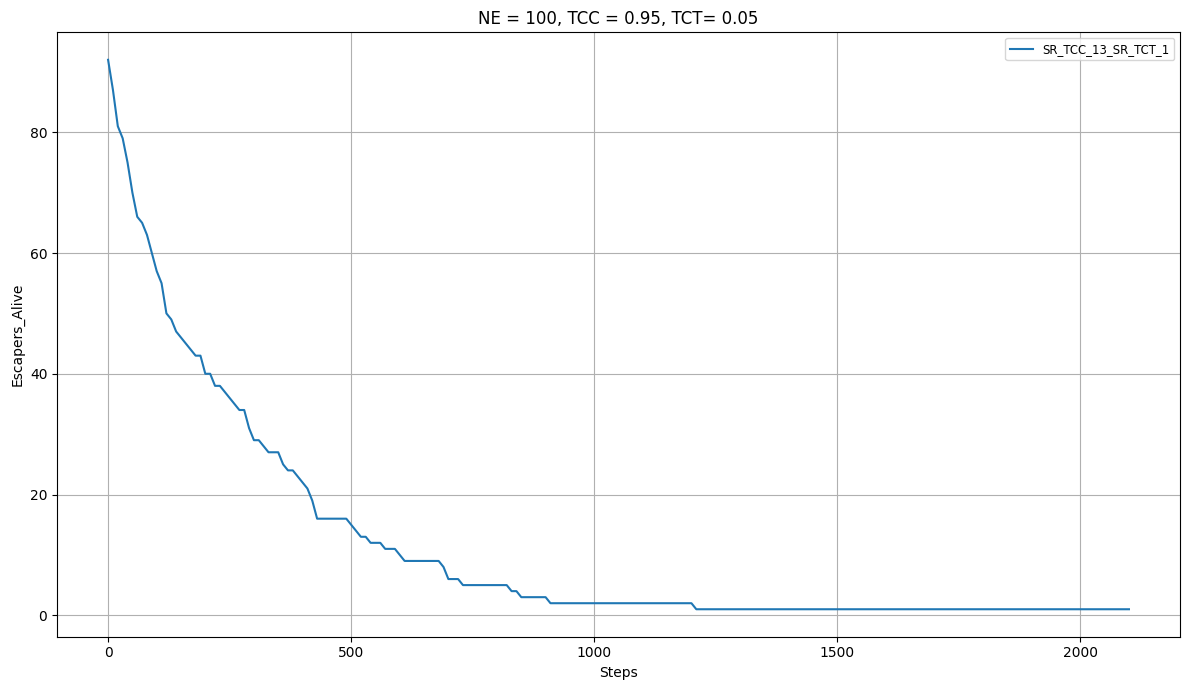

In [124]:
chaves = ["SR_TCC_13_SR_TCT_1"]
plotar_curvas(df_NC_500_NE_100_TCC_095_TCT_005_O_0, chaves,titulo='NE = 100, TCC = 0.95, TCT= 0.05', 
              salvar_pdf=True, nome_pdf="NE_100_TCC_095_TCT_005.pdf", mostrar=True)

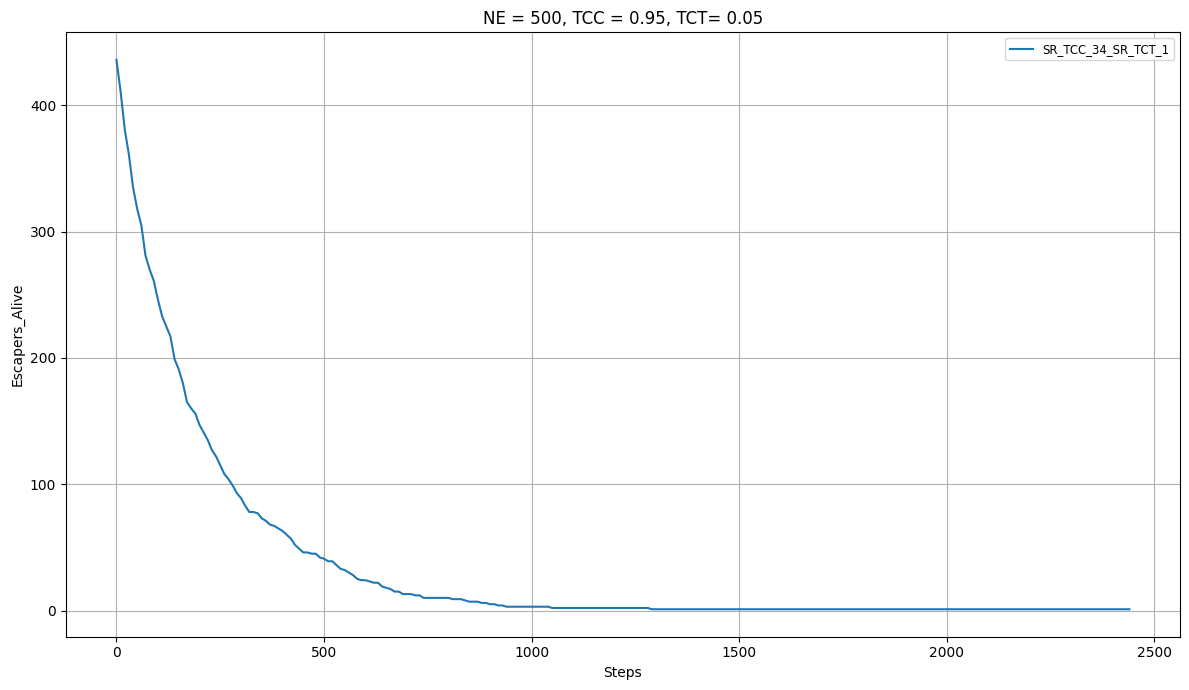

In [121]:
chaves = ["SR_TCC_34_SR_TCT_1"]
plotar_curvas(df_NC_500_NE_500_TCC_095_TCT_005_O_0, chaves,titulo='NE = 500, TCC = 0.95, TCT= 0.05', 
              salvar_pdf=True, nome_pdf="NE_500_TCC_095_TCT_005.pdf", mostrar=True)

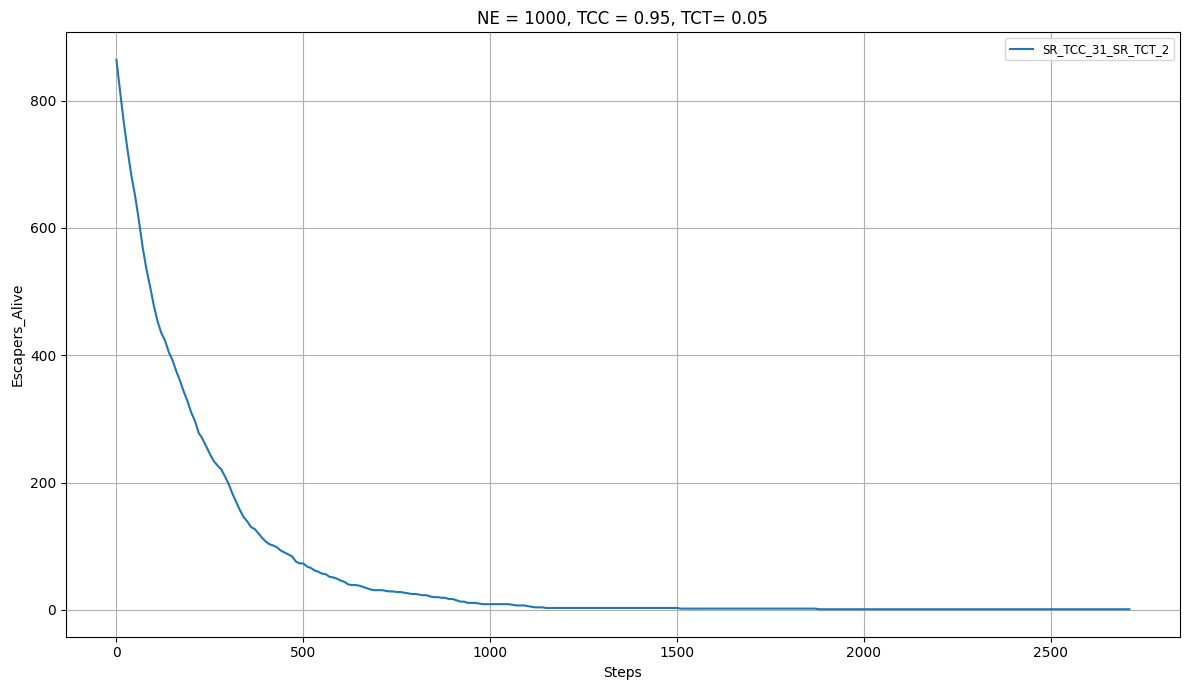

In [120]:
chaves = ["SR_TCC_31_SR_TCT_2"]
plotar_curvas(df_NC_500_NE_1000_TCC_095_TCT_005_O_0, chaves,titulo='NE = 1000, TCC = 0.95, TCT= 0.05', 
              salvar_pdf=True, nome_pdf="NE_1000_TCC_095_TCT_005.pdf", mostrar=True)

In [129]:
chave, df_mais_longo, passo_final = encontrar_df_com_mais_passos(df_NC_500_NE_100_TCC_095_TCT_005_O_0)

print(f"DataFrame com mais passos: {chave}")
print(f"Último passo registrado: {passo_final}")
print(df_mais_longo.tail())  # mostra o início da curva

DataFrame com mais passos: SR_TCC_13_SR_TCT_1
Último passo registrado: 2100
     passo  presas_vivas
206   2060             1
207   2070             1
208   2080             1
209   2090             1
210   2100             1


In [ ]:
# Organize seus dados
df_SR05 =[
    df_NP500_NH500_TCC_005_TCT_005_O_00_SR05,
    df_NP500_NH500_TCC_005_TCT_005_O_02_SR05,
    df_NP500_NH500_TCC_005_TCT_005_O_03_SR05,
    df_NP500_NH500_TCC_005_TCT_005_O_05_SR05,
    df_NP500_NH500_TCC_005_TCT_005_O_06_SR05,
    df_NP500_NH500_TCC_005_TCT_005_O_11_SR05,
    df_NP500_NH500_TCC_005_TCT_005_O_21_SR05,
    df_NP500_NH500_TCC_005_TCT_005_O_26_SR05,
    df_NP500_NH500_TCC_005_TCT_005_O_51_SR05
    ]

df_SR10 =[
    df_NP500_NH500_TCC_005_TCT_005_O_00_SR10,
    df_NP500_NH500_TCC_005_TCT_005_O_02_SR10,
    df_NP500_NH500_TCC_005_TCT_005_O_03_SR10,
    df_NP500_NH500_TCC_005_TCT_005_O_05_SR10,
    df_NP500_NH500_TCC_005_TCT_005_O_06_SR10,
    df_NP500_NH500_TCC_005_TCT_005_O_11_SR10,
    df_NP500_NH500_TCC_005_TCT_005_O_21_SR10,
    df_NP500_NH500_TCC_005_TCT_005_O_26_SR10,
    df_NP500_NH500_TCC_005_TCT_005_O_51_SR10
    ]

df_SR20 =[
    df_NP500_NH500_TCC_005_TCT_005_O_00_SR20,
    df_NP500_NH500_TCC_005_TCT_005_O_02_SR20,
    df_NP500_NH500_TCC_005_TCT_005_O_03_SR20,
    df_NP500_NH500_TCC_005_TCT_005_O_05_SR20,
    df_NP500_NH500_TCC_005_TCT_005_O_06_SR20,
    df_NP500_NH500_TCC_005_TCT_005_O_11_SR20,
    df_NP500_NH500_TCC_005_TCT_005_O_21_SR20,
    df_NP500_NH500_TCC_005_TCT_005_O_26_SR20,
    df_NP500_NH500_TCC_005_TCT_005_O_51_SR20
    ]
df_SR30=[
    df_NP500_NH500_TCC_005_TCT_005_O_00_SR30,
    df_NP500_NH500_TCC_005_TCT_005_O_02_SR30,
    df_NP500_NH500_TCC_005_TCT_005_O_03_SR30,
    df_NP500_NH500_TCC_005_TCT_005_O_05_SR30,
    df_NP500_NH500_TCC_005_TCT_005_O_06_SR30,
    df_NP500_NH500_TCC_005_TCT_005_O_11_SR30,
    df_NP500_NH500_TCC_005_TCT_005_O_21_SR30,
    df_NP500_NH500_TCC_005_TCT_005_O_26_SR30,
    df_NP500_NH500_TCC_005_TCT_005_O_51_SR30
    ]
df_SR40 =[
    df_NP500_NH500_TCC_005_TCT_005_O_00_SR40,
    df_NP500_NH500_TCC_005_TCT_005_O_02_SR40,
    df_NP500_NH500_TCC_005_TCT_005_O_03_SR40,
    df_NP500_NH500_TCC_005_TCT_005_O_05_SR40,
    df_NP500_NH500_TCC_005_TCT_005_O_06_SR40,
    df_NP500_NH500_TCC_005_TCT_005_O_11_SR40,
    df_NP500_NH500_TCC_005_TCT_005_O_21_SR40,
    df_NP500_NH500_TCC_005_TCT_005_O_26_SR40,
    df_NP500_NH500_TCC_005_TCT_005_O_51_SR40
    ]
df_SR50 =[
    df_NP500_NH500_TCC_005_TCT_005_O_00_SR50,
    df_NP500_NH500_TCC_005_TCT_005_O_02_SR50,
    df_NP500_NH500_TCC_005_TCT_005_O_03_SR50,
    df_NP500_NH500_TCC_005_TCT_005_O_05_SR50,
    df_NP500_NH500_TCC_005_TCT_005_O_06_SR50,
    df_NP500_NH500_TCC_005_TCT_005_O_11_SR50,
    df_NP500_NH500_TCC_005_TCT_005_O_21_SR50,
    df_NP500_NH500_TCC_005_TCT_005_O_26_SR50,
    df_NP500_NH500_TCC_005_TCT_005_O_51_SR50
    ]

dataframes_by_sr = [df_SR05, df_SR10, df_SR20, df_SR30, df_SR40, df_SR50]
o_values = [0, 2, 3, 5, 6, 11, 21, 26, 51]
sr_labels = ['05', '10', '20', '30', '40', '50']

# Exemplo 2 - Totalmente personalizado
ax1 = plot_heatmap(
    dataframes=dataframes_by_sr,
    row_labels=sr_labels,
    col_labels=o_values,
    title="$N_{C}^{0}=500, N_{E}=500 $",
    xlabel="$n^{R}_{R}$",
    ylabel="$SR^{R}_{R}$",
    cbar_label="Média",
    annot=False,
    cmap="coolwarm",
    figsize=(12, 6),
    linewidths=0.5,
    linecolor='white')
plt.savefig("H.M_NP500_NH500_R_R.pdf", format='pdf')
plt.show()